# Stochastic Gradient Descent

## Step 0: Get Iris data

In [4]:
import os
import numpy as np
import pandas as pd

try:
    s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
    print('From URL:', s)
    df = pd.read_csv(s,
                     header=None,
                     encoding='utf-8')

except HTTPError:
    s = 'iris.data'
    print('From local Iris path:', s)
    df = pd.read_csv(s,
                     header=None,
                     encoding='utf-8')

n_unique_categories = df[4].nunique()
unique_categories = df[4].unique()
print(f"There are {n_unique_categories} categories: {unique_categories}")

df.tail()

From URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
There are 3 categories: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Fitting a dataset with X: (100, 2) and y: (100,)


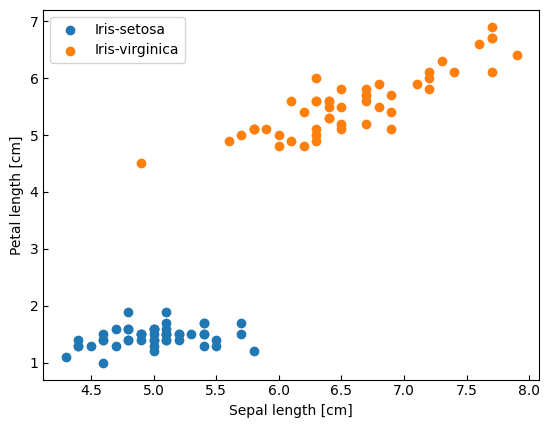

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# We are going to classify Iris-setosa from Iris virginica
labels = ['Iris-setosa', 'Iris-virginica']
mask = df[4].isin(labels)
df = df.loc[mask]

X = df[[0, 2]].values
y = df[4].values
y_mapped = np.zeros(y.shape, dtype=int)
y_mapped[y == labels[1]] = 1

print(f"Fitting a dataset with X: {X.shape} and y: {y.shape}")

ax = plt.figure().gca()
for label in labels:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], label=label)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')
ax.legend()

## Step 1: Define base Adaline class with Gradient Descent

In [45]:
import numpy as np

class AdalineGD:
    """ Full-batch gradient descent variant
        
        Parameters:
        -----------
        eta : float - Learning rate between 0 and 1
        n_iter : int - Iterations over the trainind ata
        random_seed : int - Random seed

        Attributes:
        -----------
        w_ : 1d array of weights
        b_ : bias term
        losses_ : MSE loss each epoch
    """
    def __init__(self, eta=0.01, n_iter=20, standardize=True, random_seed=42):
        self.eta = eta
        self.n_iter = n_iter
        self.standardize = standardize
        self.random_seed = random_seed

    def fit(self, X, y):
        """ X : ndarray with shape [n_examples, n_features]
            y : ndarray with shape [n_examples,]
        """
        self.rng = np.random.default_rng(seed=self.random_seed)
        self.w_ = self.rng.normal(loc=0, scale=0.01, size=X.shape[1])
        self.b_ = np.float_(0.)

        self.losses_ = []

        # Collect mean/std for inputs since we know standardization helps
        if self.standardize:
            self.X_mean_ = X.mean(axis=0)
            self.X_std_ = X.std(axis=0)
        else:
            self.X_mean_ = 0.
            self.X_std_ = 1.

        X_std = self._standardize(X)

        # iterate over epochs
        for _ in range(self.n_iter):
             loss = self._fit_epoch(X_std, y)
             self.losses_.append(loss)

        return self

    def _fit_epoch(self, X, y):
        diff = y - self.pre_threshold(X)
        self.w_ += 2. * self.eta * diff.dot(X) / X.shape[0]
        self.b_ += 2. * self.eta * diff.mean()

        loss = np.power(diff, 2).mean()
        return loss

    def _standardize(self, X):
        return (X - self.X_mean_) / self.X_std_

    def pre_threshold(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        z = self.pre_threshold(self._standardize(X))
        return np.where(z >= 0.5, 1, 0)

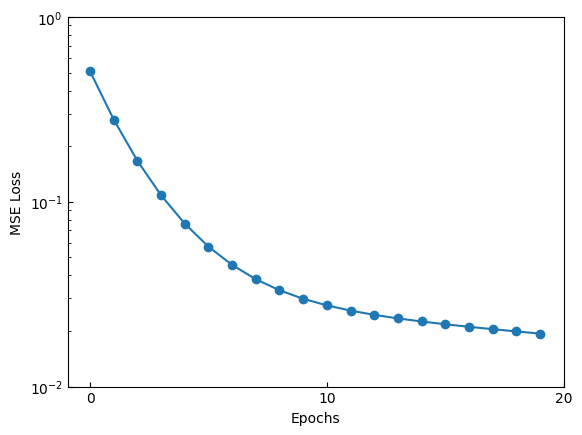

In [46]:
gd_model = AdalineGD(eta=0.1, n_iter=20, standardize=True)
gd_model.fit(X, y_mapped)

ax = plt.figure().gca()
ax.plot(gd_model.losses_, marker='o')
ax.set(xlabel='Epochs', xticks=[0, 10, 20],
       ylabel='MSE Loss', yscale='log', ylim=[1e-2, 1e0]);

In [84]:
class AdalineSGD(AdalineGD):
    def _shuffle(self, X, y):
        """ Shuffle training data each epoch"""
        r = self.rng.permutation(X.shape[0])
        return X[r, :], y[r]

    def _fit_epoch(self, X, y):
        X_shuf, y_shuf = self._shuffle(X, y)

        loss = 0.

        for xi, yi in zip(X_shuf, y_shuf):
            diff = yi - self.pre_threshold(xi)
            self.w_ += 2. * self.eta * xi * diff
            self.b_ += 2. * self.eta * diff

            loss += diff**2

        return loss / X.shape[0]

class AdalineMiniBatchSGD(AdalineGD):
    def __init__(self, batch_size=32, **kwargs):
        self.batch_size=batch_size
        super().__init__(**kwargs)

    def _shuffle(self, X, y):
        """ Shuffle training data each epoch"""
        r = self.rng.permutation(X.shape[0])
        return X[r, :], y[r]

    def _fit_epoch(self, X, y):
        X_shuf, y_shuf = self._shuffle(X, y)

        loss = 0.
        count = 0

        for batch_start in range(0, X.shape[0], self.batch_size):
            batch_end = batch_start + self.batch_size
            Xb = X_shuf[batch_start:batch_end, :]
            yb = y_shuf[batch_start:batch_end]

            diff = yb - self.pre_threshold(Xb)
            self.w_ += 2. * self.eta * diff.dot(Xb) / Xb.shape[0]
            self.b_ += 2. * self.eta * diff.mean()

            loss += np.mean(diff**2)
            count += 1

        return loss / count

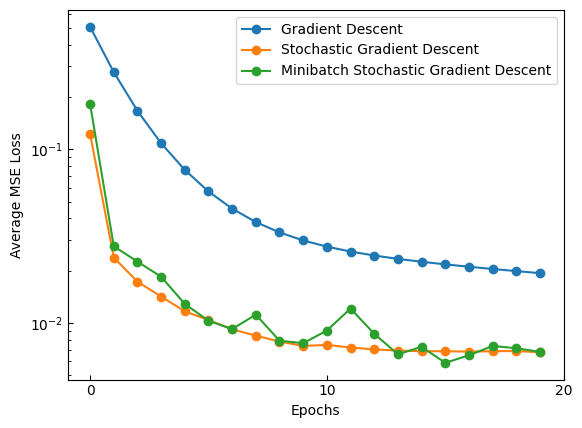

In [98]:
sgd_model = AdalineSGD(eta=0.01, n_iter=20)
sgd_model.fit(X, y_mapped)

minibatch_model = AdalineMiniBatchSGD(eta=0.2, n_iter=20, batch_size=32)
minibatch_model.fit(X, y_mapped)

ax = plt.figure().gca()
ax.plot(gd_model.losses_, marker='o', label='Gradient Descent')
ax.plot(sgd_model.losses_, marker='o', label='Stochastic Gradient Descent')
ax.plot(minibatch_model.losses_, marker='o', label='Minibatch Stochastic Gradient Descent')

ax.set(xlabel='Epochs', xticks=[0, 10, 20],
       ylabel='Average MSE Loss', yscale='log');
ax.legend()

[Text(0.5, 0, 'Sepal length [cm]'), Text(0, 0.5, 'Petal length [cm]')]

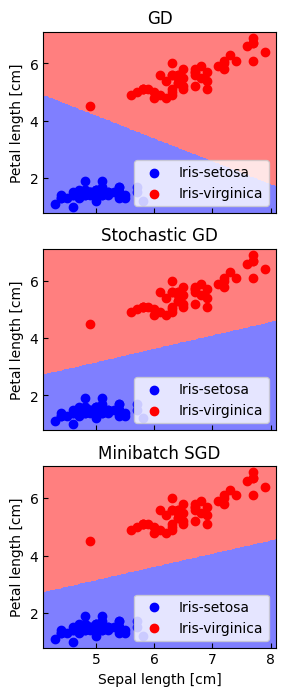

In [99]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.02, colors=['blue', 'red'], labels=None):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min()-10*d, X[:, 0].max()+10*d, d),
        np.arange(X[:, 1].min()-10*d, X[:, 1].max()+10*d, d),
    )
    y_model = model.predict(np.stack([x1.ravel(), x2.ravel()]).T)
    y_model = y_model.reshape(x1.shape)

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for ii, label in enumerate(np.unique(y)):
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], color=colors[label], label=labels[label] if labels else None)
    ax.legend(loc='lower right')
    return ax

fig, ax = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(3, 8), dpi=100)
plot_decision_boundary(ax[0], X, y_mapped, gd_model, labels=labels).set_title('GD')
plot_decision_boundary(ax[1], X, y_mapped, sgd_model, labels=labels).set_title('Stochastic GD')
plot_decision_boundary(ax[2], X, y_mapped, minibatch_model, labels=labels).set_title('Minibatch SGD')

ax[0].set(ylabel='Petal length [cm]')
ax[1].set(ylabel='Petal length [cm]')
ax[2].set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')